# 2D Compressible Euler Solver — API Test Notebook

Interactive visual sanity checks for the `numerical_solvers.euler2d` public API:
- 2D Sod along x: cross-section comparison against the 1D Euler solver (should agree to floating-point precision).
- Liska–Wendroff 2D Riemann Config 3 (four-shock quadrant test), the standard PyClaw benchmark.
- Flux comparison HLLC / HLL / Rusanov on Config 3.
- Batch generation via `generate_n`.

Riemann kernels ported from clawpack/riemann `euler_1D_py.py` with passive tangential momentum; ICs from Liska–Wendroff (SIAM J. Sci. Comput. 2003).

In [1]:
import torch
import matplotlib.pyplot as plt

from numerical_solvers.src import euler, euler2d

%matplotlib inline

GAMMA = 1.4

## 1. 2D Sod along x: cross-section matches 1D Euler

The 2D solver on a y-invariant Sod initial condition must reproduce the 1D Euler Sod solution on every y-row. This is the decisive consistency check.

2D valid: True


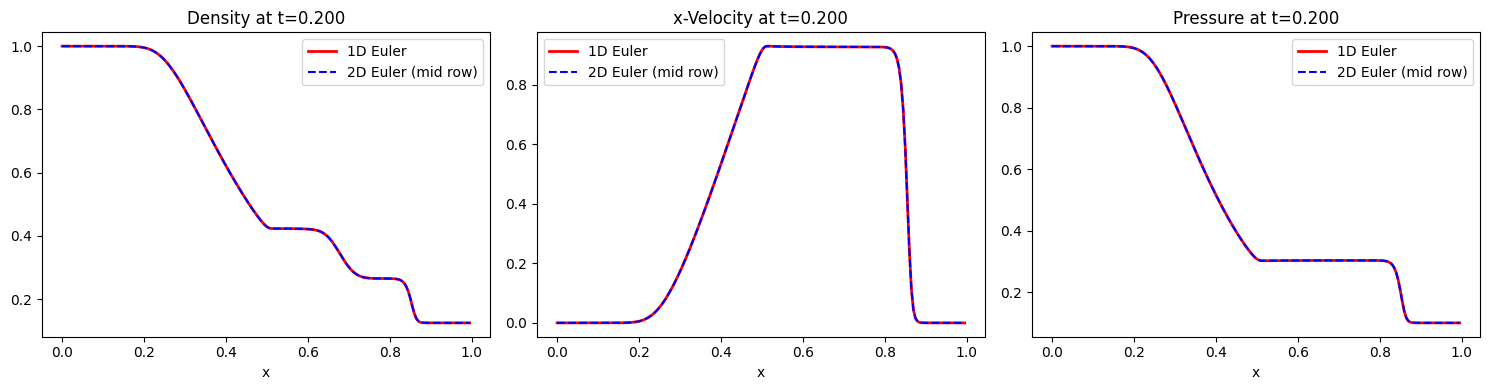

Max |rho_2d - rho_1d| at mid row: 2.554e-15
Max |v| (should be ~0): 0.000e+00


In [2]:
nx, ny = 200, 20
dx = 1.0 / nx; dy = 0.05
dt = 0.0005; nt = 400
x = torch.arange(nx, dtype=torch.float64) * dx
y = torch.arange(ny, dtype=torch.float64) * dy

# 2D
rho0, u0, v0, p0 = euler2d.sod_x(x, y, x_split=0.5)
out2d = euler2d.generate_one(rho0, u0, v0, p0, dx=dx, dy=dy, dt=dt, nt=nt,
                             flux_type='hllc', reconstruction='constant', gamma=GAMMA)
print('2D valid:', out2d['valid'])

# 1D reference
rho1, u1, p1 = euler.sod(x, x_split=0.5)
out1d = euler.generate_one(rho1, u1, p1, dx=dx, dt=dt, nt=nt,
                           flux_type='hllc', reconstruction='constant', gamma=GAMMA)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
mid = ny // 2
for ax, key, title in zip(axes, ['rho', 'u', 'p'], ['Density', 'x-Velocity', 'Pressure']):
    ax.plot(out1d['x'].numpy(), out1d[key][-1].numpy(), 'r-', lw=2, label='1D Euler')
    ax.plot(out2d['x'].numpy(), out2d[key][-1, mid].numpy(), 'b--', lw=1.5, label='2D Euler (mid row)')
    ax.set_xlabel('x'); ax.set_title(f'{title} at t={out2d["t"][-1]:.3f}'); ax.legend()
fig.tight_layout(); plt.show()

max_err = (out2d['rho'][-1, mid] - out1d['rho'][-1]).abs().max().item()
print(f'Max |rho_2d - rho_1d| at mid row: {max_err:.3e}')
print(f'Max |v| (should be ~0): {out2d["v"][-1].abs().max().item():.3e}')

## 2. Liska–Wendroff Configuration 3

Four-shock quadrant test from the PyClaw gallery: we should see two shocks forming the diagonal interaction visible in the canonical density contour plot.

valid: True  t_final = 0.8


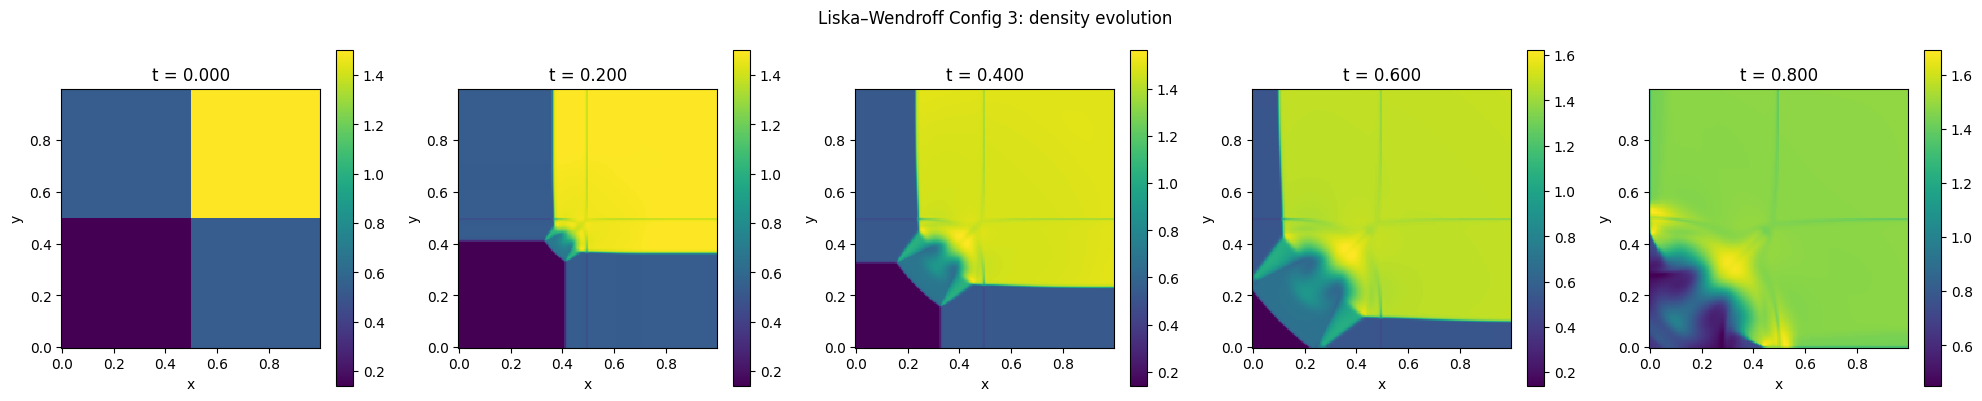

In [3]:
nx = ny = 200
dx = dy = 1.0 / nx
dt = 0.02; nt = 40
x = torch.arange(nx, dtype=torch.float64) * dx
y = torch.arange(ny, dtype=torch.float64) * dy

rho0, u0, v0, p0 = euler2d.liska_wendroff(x, y, config=3)
out = euler2d.generate_one(rho0, u0, v0, p0, dx=dx, dy=dy, dt=dt, nt=nt,
                           flux_type='hllc', reconstruction='constant', gamma=GAMMA,
                           bc_type='extrap')
print('valid:', out['valid'], ' t_final =', float(out['t'][-1]))

times_to_show = [0, nt // 4, nt // 2, 3 * nt // 4, nt]
fig, axes = plt.subplots(1, len(times_to_show), figsize=(4 * len(times_to_show), 4))
for ax, t_idx in zip(axes, times_to_show):
    c = ax.pcolormesh(out['x'].numpy(), out['y'].numpy(), out['rho'][t_idx].numpy(),
                       cmap='viridis', shading='auto')
    fig.colorbar(c, ax=ax)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f't = {out["t"][t_idx]:.3f}')
    ax.set_aspect('equal')
fig.suptitle('Liska–Wendroff Config 3: density evolution')
fig.tight_layout(); plt.show()

## 3. Flux comparison on Config 3

Run the same IC with HLLC, HLL, and Rusanov fluxes to compare resolution. HLLC should resolve contact discontinuities most sharply; Rusanov is the most diffusive.

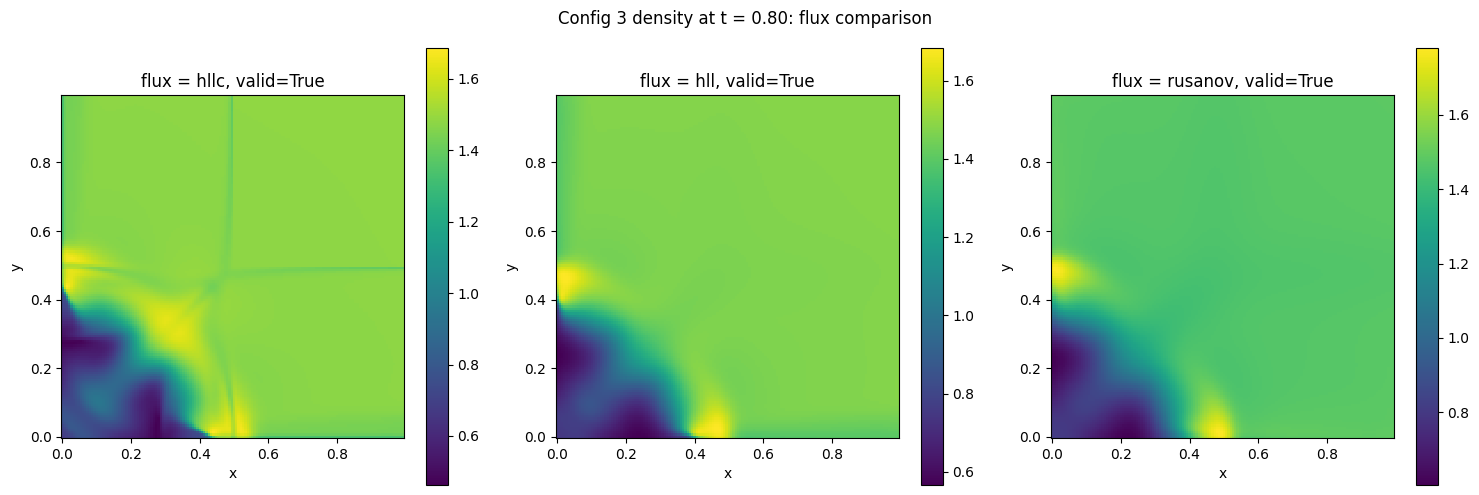

In [4]:
nx = ny = 150
dx = dy = 1.0 / nx
dt = 0.02; nt = 40
x = torch.arange(nx, dtype=torch.float64) * dx
y = torch.arange(ny, dtype=torch.float64) * dy
rho0, u0, v0, p0 = euler2d.liska_wendroff(x, y, config=3)

fluxes = ['hllc', 'hll', 'rusanov']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, flux in zip(axes, fluxes):
    out = euler2d.generate_one(rho0, u0, v0, p0, dx=dx, dy=dy, dt=dt, nt=nt,
                               flux_type=flux, reconstruction='constant', gamma=GAMMA)
    c = ax.pcolormesh(out['x'].numpy(), out['y'].numpy(), out['rho'][-1].numpy(),
                       cmap='viridis', shading='auto')
    fig.colorbar(c, ax=ax); ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f'flux = {flux}, valid={out["valid"]}')
    ax.set_aspect('equal')
fig.suptitle(f'Config 3 density at t = {dt*nt:.2f}: flux comparison')
fig.tight_layout(); plt.show()

## 4. Batch generation via `generate_n`

rho shape: torch.Size([4, 21, 60, 60])
ic_rho_ks shape: (4, 3, 3)


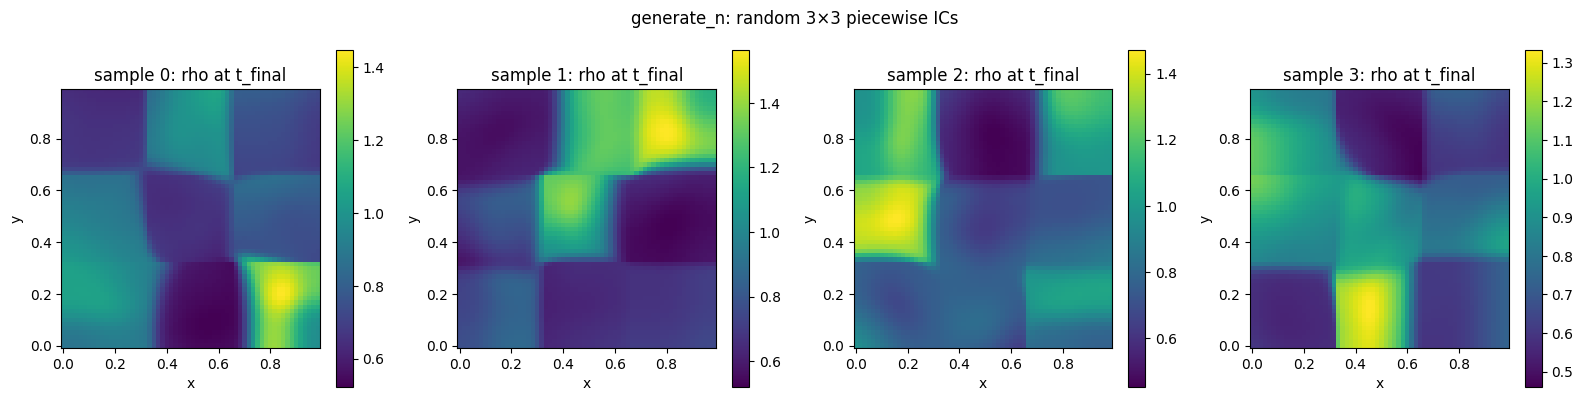

In [5]:
batch = euler2d.generate_n(
    n=4, kx=3, ky=3, nx=60, ny=60,
    dx=1.0/60, dy=1.0/60, dt=0.01, nt=20,
    seed=7, reconstruction='constant', show_progress=False,
    rho_range=(0.5, 1.2), u_range=(-0.3, 0.3),
    v_range=(-0.3, 0.3), p_range=(0.5, 1.2),
)
print('rho shape:', batch['rho'].shape)
print('ic_rho_ks shape:', batch['ic_rho_ks'].shape)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, range(4)):
    c = ax.pcolormesh(batch['x'].numpy(), batch['y'].numpy(), batch['rho'][i, -1].numpy(),
                       cmap='viridis', shading='auto')
    fig.colorbar(c, ax=ax); ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f'sample {i}: rho at t_final')
    ax.set_aspect('equal')
fig.suptitle('generate_n: random 3×3 piecewise ICs')
fig.tight_layout(); plt.show()